In [1]:
import random
import numpy as np
import os
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import json
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [3]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
DATA_DIR = os.path.join(path, "plantvillage", "PlantVillage")

classes = sorted(os.listdir(DATA_DIR))
print("Total classes:", len(classes))


Using Colab cache for faster access to the 'plantdisease' dataset.
Total classes: 15


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [5]:
class_indices = {v: k for k, v in train_generator.class_indices.items()}

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=4)


In [6]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_indices), activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,963,535 (18.93 MB)

 Trainable params: 4,963,535 (18.93 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 343s 646ms/step - accuracy: 0.4326 - loss: 1.7527 - val_accuracy: 0.5609 - val_loss: 1.3225
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 229s 442ms/step - accuracy: 0.6508 - loss: 1.0560 - val_accuracy: 0.6567 - val_loss: 0.9877
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 259s 436ms/step - accuracy: 0.7240 - loss: 0.8239 - val_accuracy: 0.7382 - val_loss: 0.7733
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 228s 440ms/step - accuracy: 0.7571 - loss: 0.7118 - val_accuracy: 0.6511 - val_loss: 1.3146
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 221s 427ms/step - accuracy: 0.7836 - loss: 0.6363 - val_accuracy: 0.8045 - val_loss: 0.5653
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 226s 436ms/step - accuracy: 0.8165 - loss: 0.5371 - val_accuracy: 0.8299 - val_loss: 0.5225
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 221s 427ms/step - accuracy: 0.8343 - loss: 0.4836 - val_accuracy: 0.8697 - val_loss: 0.3947
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 222s 428ms/step - accuracy: 0.8535 -

In [8]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9078 - loss: 0.2689
Validation Accuracy: 90.78%
Validation Loss: 0.2689


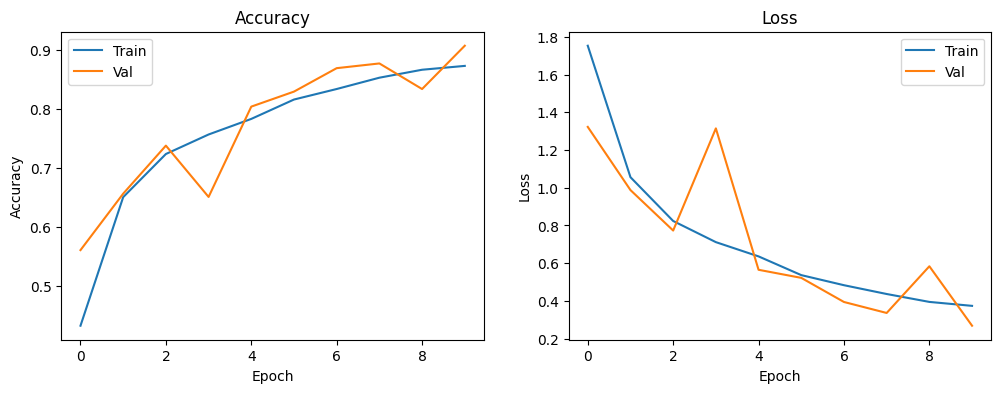

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [10]:
def predict_disease(model, image_path, class_indices):
    img = Image.open(image_path)
    if img.mode != "RGB":
        img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0]
    predicted_class_index = int(np.argmax(prediction))
    predicted_class = class_indices.get(predicted_class_index, f"Class {predicted_class_index}")
    confidence = float(prediction[predicted_class_index]) * 100
    return predicted_class, confidence


In [11]:
model.save("plant_disease_model.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('disease_model.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpr7vyvbh4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  134855741795664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741795472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741796432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741797200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741797008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741797584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741796240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741797776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741796816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134855741798160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1348557417973